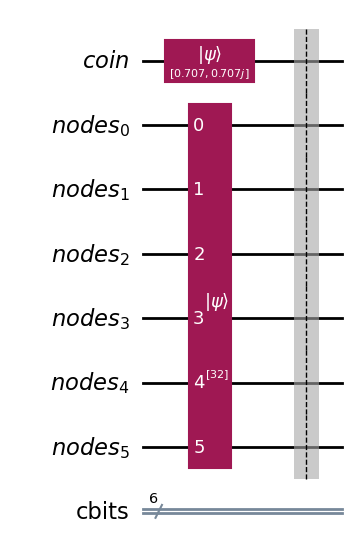

In [2]:
"""
Implementation of a QRNG using a Hadamard quantum walk
"""

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
import numpy as np
from n_cycle_gates import shift_gate

# Set number of bits for the random number
n_bits = 6

initial_value = 32

# Initialize a register with n_bits qubits
qubits = QuantumRegister(n_bits, "nodes")

# Initialize a coin register for the QW with 1 bit
coin = QuantumRegister(1, "coin")

classical = ClassicalRegister(n_bits, "cbits")

qc = QuantumCircuit(coin, qubits, classical)

qc.initialize([1/np.sqrt(2), 1j/np.sqrt(2)], coin)

# Initialize position qubits to the state |4>
qc.initialize(initial_value, qubits)
qc.barrier()
qc.draw('mpl')

In [3]:
# Set number of steps of walk
n_steps = 11

# Create circuit for n_steps of walk
for i in range(n_steps):
    qc.h(coin)
    qc.append(shift_gate(qubits, function=0), [qubit for reg in qc.qregs for qubit in reg])
    qc.append(shift_gate(qubits, function=1), [qubit for reg in qc.qregs for qubit in reg])
    qc.barrier()

qc.measure(qubits, classical)
#qc.draw('mpl')

In [4]:
# Implement classical simulation of the above QW
simulator = AerSimulator()
qct = transpile(qc, simulator)
counts = simulator.run(qct, shots=1).result().get_counts()

# Get a random number (binary) from the quantum-walk-circuit
b_num = list(counts.keys())[0]
print("Random number (binary representation): ", b_num)

# Convert to decimal and print
decimal = int(b_num, 2)
print("\nRandom number in decimal: ", decimal)


Random number (binary representation):  011111

Random number in decimal:  31
